<a href="https://colab.research.google.com/github/anafrodrigues95-rgc/geomodelagem_uenf/blob/main/acaibarbeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Instala o ultralytics e o roboflow atualizando o setuptools para evitar conflitos
!pip install --upgrade setuptools
!pip install roboflow ultralytics

# Força a reinstalação segura de dependências do PyTorch se necessário
# (Geralmente apenas reiniciar o ambiente após o pip install acima já resolve)

  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [1]:
import os
from roboflow import Roboflow

# --- CONFIGURAÇÃO ÚNICA DA SUA IDENTIDADE ---
API_KEY = "JvE3dIqiHY5XNHhSOQ5p"
WORKSPACE = "anas-workspace-5npb9"
PROJECT_NAME = "acai-v4l4k"
VERSION_NUMBER = 2  # Versão 2 que contém Açaí e Barbeiro

# Inicializando o Roboflow e baixando o dataset atualizado
rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)
dataset = version.download("yolov11")

print(f"\nDataset baixado com sucesso em: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...

Dataset baixado com sucesso em: /content/açai-2


In [6]:
from ultralytics import YOLO
import os

# Mudamos para o modelo 'm' (Medium). Ele é mais "teimoso" e erra menos a identidade das classes
model = YOLO("yolo11m-seg.pt")

model.train(
    data=os.path.join(dataset.location, "data.yaml"),
    epochs=60,          # 60 épocas é o ponto ideal para o modelo médio convergir sem viciar
    imgsz=640,
    batch=16,           # Como o modelo M é mais leve, podemos usar batch 16 (mais estável)
    workers=4,
    project="usmb-3ou0v",
    name="exp_acai_barbeiro_anti_confusao",

    # --- PARÂMETROS CIRÚRGICOS PARA SEPARAR AS CLASSES ---
    patience=15,
    box=7.5,
    cls=3.0,            # Triplicamos o peso da classificação. Se ele chamar barbeiro de açaí, o erro penaliza muito o modelo

    # Desativamos o 'mixup' (pois ele mistura fotos e pode estar fundindo açaí com barbeiro na mente do modelo)
    mosaic=1.0,         # Mantido para ajudar no tamanho do barbeiro
    mixup=0.0,          # DESATIVADO para evitar a fusão visual das duas classes
    degrees=15.0,
    fliplr=0.5
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/açai-2/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_acai_barbeiro_anti_confusao, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f116e1ebb00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

[INFO] Avaliando imagens com o novo modelo focado em separação de classes...

--- [Foto 1] WhatsApp-Image-2026-07-03-at-11-39-13_jpeg.rf.b5a8a74a4903df3ea3339133ec3b2aef.jpg ---

image 1/1 /content/açai-2/valid/images/WhatsApp-Image-2026-07-03-at-11-39-13_jpeg.rf.b5a8a74a4903df3ea3339133ec3b2aef.jpg: 640x640 2 a-ais, 77.4ms
Speed: 14.5ms preprocess, 77.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-6
   ↳ a-ai detectado com 0.71 de certeza.
   ↳ a-ai detectado com 0.50 de certeza.


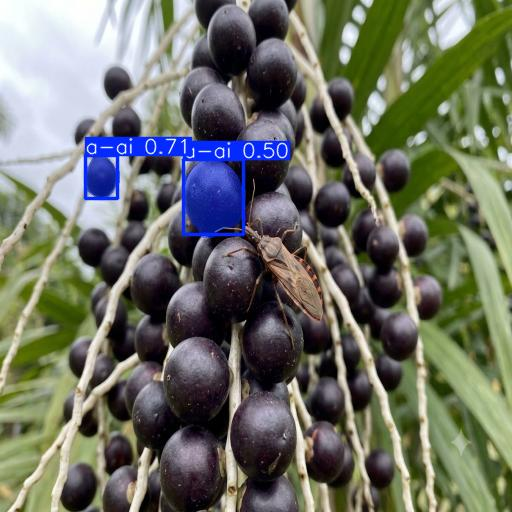

------------------------------------------------------------
--- [Foto 2] 151480040m_jpg.rf.a7eb49e9723eeb00092b6eca0d2a077b.jpg ---

image 1/1 /content/açai-2/valid/images/151480040m_jpg.rf.a7eb49e9723eeb00092b6eca0d2a077b.jpg: 640x640 (no detections), 50.1ms
Speed: 3.6ms preprocess, 50.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-6
   ❌ Nenhum objeto passou pelo filtro de alta certeza de classe.

--- [Foto 3] barbeiroinseto_jpg.rf.fd965fb0ba21ae664b805d80446eee85.jpg ---

image 1/1 /content/açai-2/valid/images/barbeiroinseto_jpg.rf.fd965fb0ba21ae664b805d80446eee85.jpg: 640x640 (no detections), 50.1ms
Speed: 3.1ms preprocess, 50.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-6
   ❌ Nenhum objeto passou pelo filtro de alta certeza de classe.

--- [Foto 4] barebabeiro_jpg.rf.cd18e4d4f0b89272cc20770e77acde35.jpg ---

image 1/1 /content/açai-2/valid/i

In [7]:
import os
import cv2
from IPython.display import Image, display
from PIL import Image as PILImage

base_image_dir = os.path.join(dataset.location, "valid", "images")

if os.path.exists(base_image_dir):
    image_files = [f for f in os.listdir(base_image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:
        imagens_para_testar = image_files[:5]
        print(f"[INFO] Avaliando imagens com o novo modelo focado em separação de classes...\n")

        for idx, image_filename in enumerate(imagens_para_testar):
            image_path = os.path.join(base_image_dir, image_filename)
            print(f"--- [Foto {idx+1}] {image_filename} ---")

            # Executa a predição com o modelo calibrado
            results = model.predict(
                image_path,
                save=True,
                conf=0.35,          # Subimos para 0.35 para garantir que só exiba detecções convictas
                iou=0.40,
                agnostic_nms=True   # Impede caixas duplicadas de classes diferentes no mesmo bicho
            )

            if results and len(results[0].boxes) > 0:
                detectados = []
                for box in results[0].boxes:
                    class_id = int(box.cls[0])
                    label = model.names[class_id]
                    confidence = float(box.conf[0])
                    detectados.append(label)
                    print(f"   ↳ {label} detectado com {confidence:.2f} de certeza.")

                # Mostra o gráfico da predição
                img_with_preds = results[0].plot()
                img_rgb = cv2.cvtColor(img_with_preds, cv2.COLOR_BGR2RGB)

                sampled_img = PILImage.fromarray(img_rgb)
                nome_resultado = f"resultado_ajuste_final_{idx}.jpg"
                sampled_img.save(nome_resultado)

                display(Image(nome_resultado))
                print("-" * 60)
            else:
                print("   ❌ Nenhum objeto passou pelo filtro de alta certeza de classe.\n")
    else:
        print(f"Nenhuma imagem encontrada em: {base_image_dir}")
else:
    print("Diretório de validação não encontrado.")